# Mutual Fund Analytics - Fund Performance Analytics

**Name:** Dion Samuel Daniel Fernando

**Project:** Bluestock Capstone Project

**Phase:** Fund Performance Analytics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("ggplot")
sns.set_style("whitegrid")

%matplotlib inline

os.makedirs("../reports", exist_ok=True)

In [3]:
perf = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")
fund = pd.read_csv("../data/01_fund_master.csv")
benchmark = pd.read_csv("../data/10_benchmark_indices.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
print("Performance Dataset")
display(perf.head())

print("\nShape:", perf.shape)

print("\nColumns:")
print(perf.columns.tolist())

Performance Dataset


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low



Shape: (40, 19)

Columns:
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


,scheme_name,fund_house,category,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,23.80
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,22.62
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,20.67
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,20.61
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,19.00
26,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,17.69


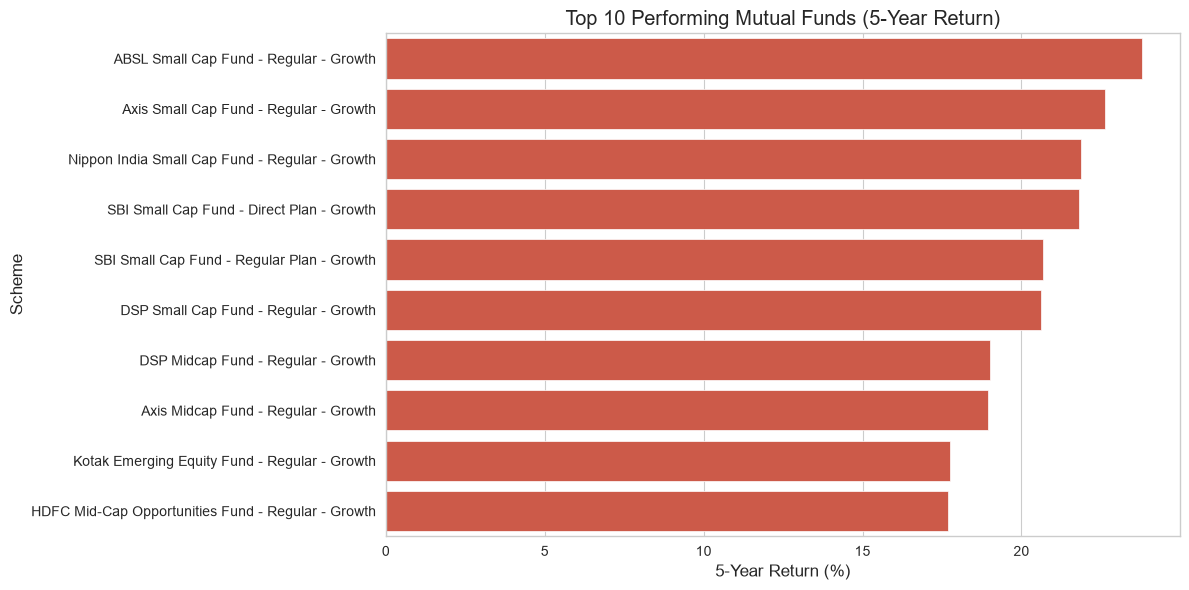

Top 10 chart saved successfully.


In [5]:
# Top 10 Performing Mutual Funds

top10 = perf.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

display(top10[[
    "scheme_name",
    "fund_house",
    "category",
    "return_5yr_pct"
]])

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Performing Mutual Funds (5-Year Return)")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../reports/top10_funds.png", dpi=300)

plt.show()

print("Top 10 chart saved successfully.")

,scheme_name,fund_house,category,return_5yr_pct
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,5.43
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,6.41
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,7.94
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,7.95
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,8.26
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,8.71
31,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Index,11.31
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,11.32
10,ICICI Pru Bluechip Fund - Regular - Growth,ICICI Prudential MF,Large Cap,11.46
18,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,12.31


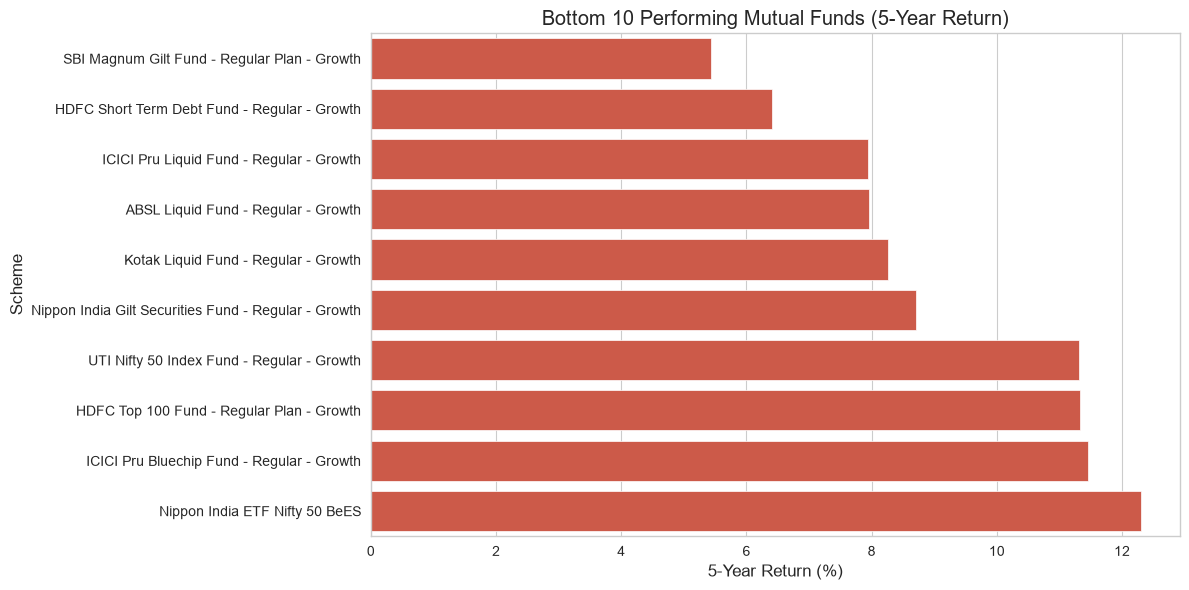

Bottom 10 chart saved successfully.


In [6]:
# Bottom 10 Performing Mutual Funds

bottom10 = perf.sort_values(
    by="return_5yr_pct",
    ascending=True
).head(10)

display(bottom10[[
    "scheme_name",
    "fund_house",
    "category",
    "return_5yr_pct"
]])

plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Bottom 10 Performing Mutual Funds (5-Year Return)")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../reports/bottom10_funds.png", dpi=300)

plt.show()

print("Bottom 10 chart saved successfully.")

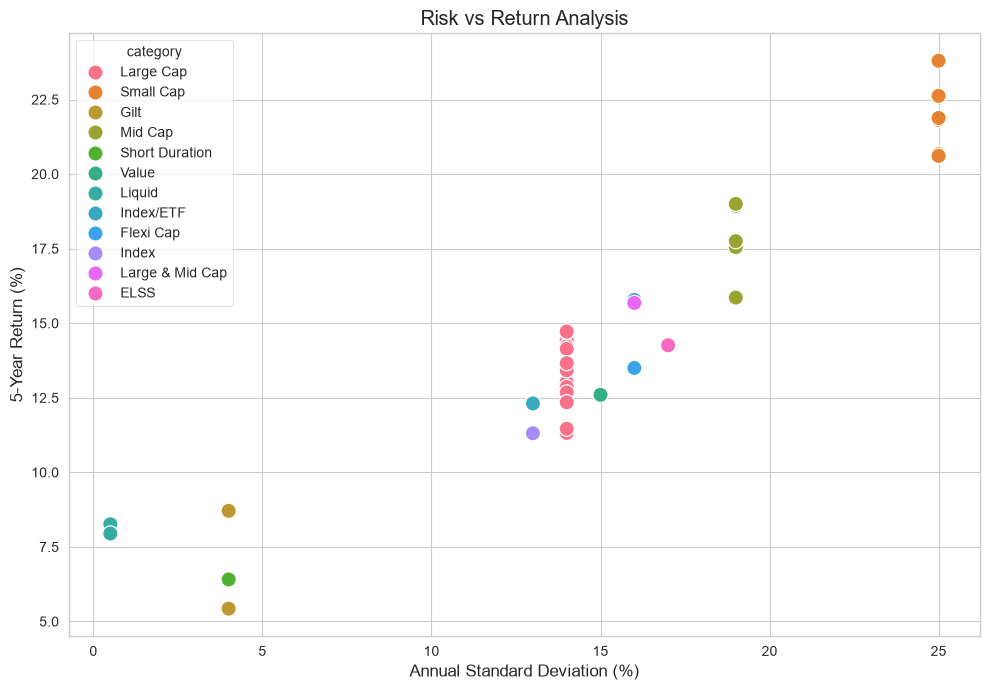

Risk vs Return chart saved.


In [7]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=perf,
    x="std_dev_ann_pct",
    y="return_5yr_pct",
    hue="category",
    s=120
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Annual Standard Deviation (%)")
plt.ylabel("5-Year Return (%)")

plt.tight_layout()

plt.savefig("../reports/risk_vs_return.png", dpi=300)

plt.show()

print("Risk vs Return chart saved.")

,scheme_name,fund_house,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,1.03
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.00


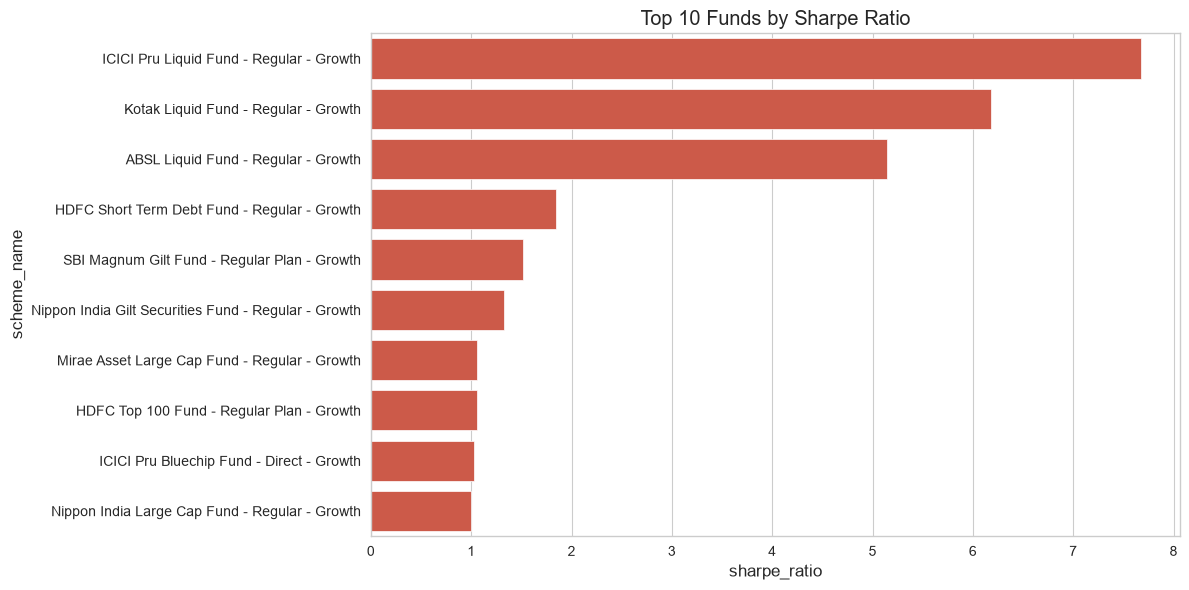

Sharpe Ratio chart saved.


In [8]:
top_sharpe = perf.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

display(top_sharpe[
    [
        "scheme_name",
        "fund_house",
        "sharpe_ratio"
    ]
])

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/sharpe_ratio.png", dpi=300)

plt.show()

print("Sharpe Ratio chart saved.")

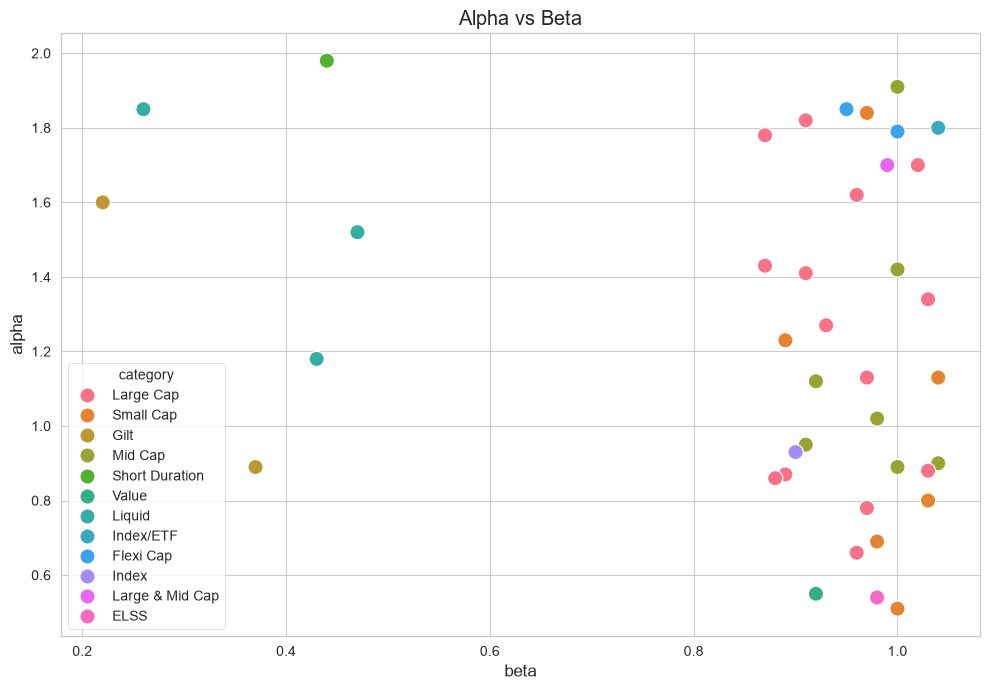

Alpha Beta chart saved.


In [9]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=perf,
    x="beta",
    y="alpha",
    hue="category",
    s=120
)

plt.title("Alpha vs Beta")

plt.tight_layout()

plt.savefig("../reports/alpha_beta.png", dpi=300)

plt.show()

print("Alpha Beta chart saved.")

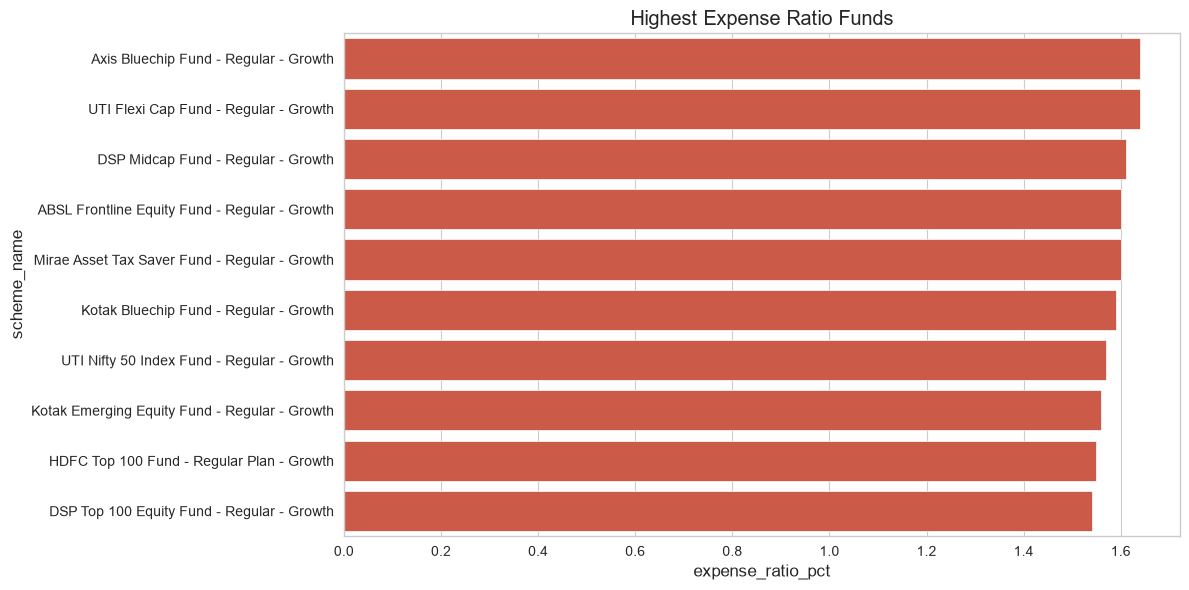

Expense Ratio chart saved.


In [10]:
expense = perf.sort_values(
    by="expense_ratio_pct",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=expense.head(10),
    x="expense_ratio_pct",
    y="scheme_name"
)

plt.title("Highest Expense Ratio Funds")

plt.tight_layout()

plt.savefig("../reports/expense_ratio.png", dpi=300)

plt.show()

print("Expense Ratio chart saved.")

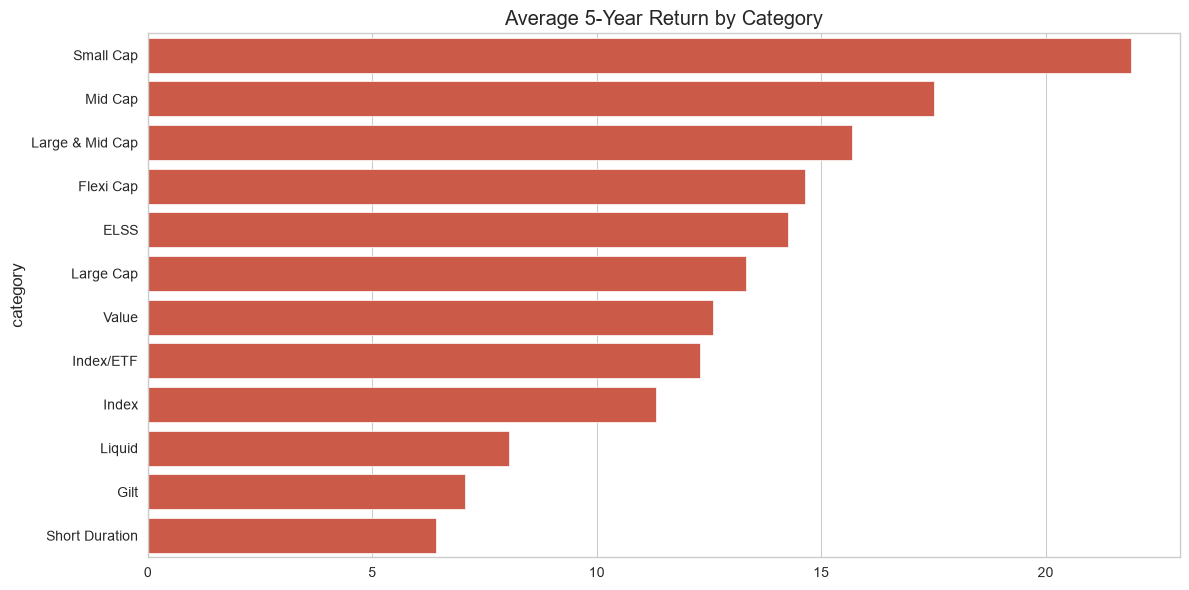

Category analysis saved.


In [11]:
cat = (
    perf.groupby("category")["return_5yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=cat.values,
    y=cat.index
)

plt.title("Average 5-Year Return by Category")

plt.tight_layout()

plt.savefig("../reports/category_return.png", dpi=300)

plt.show()

print("Category analysis saved.")

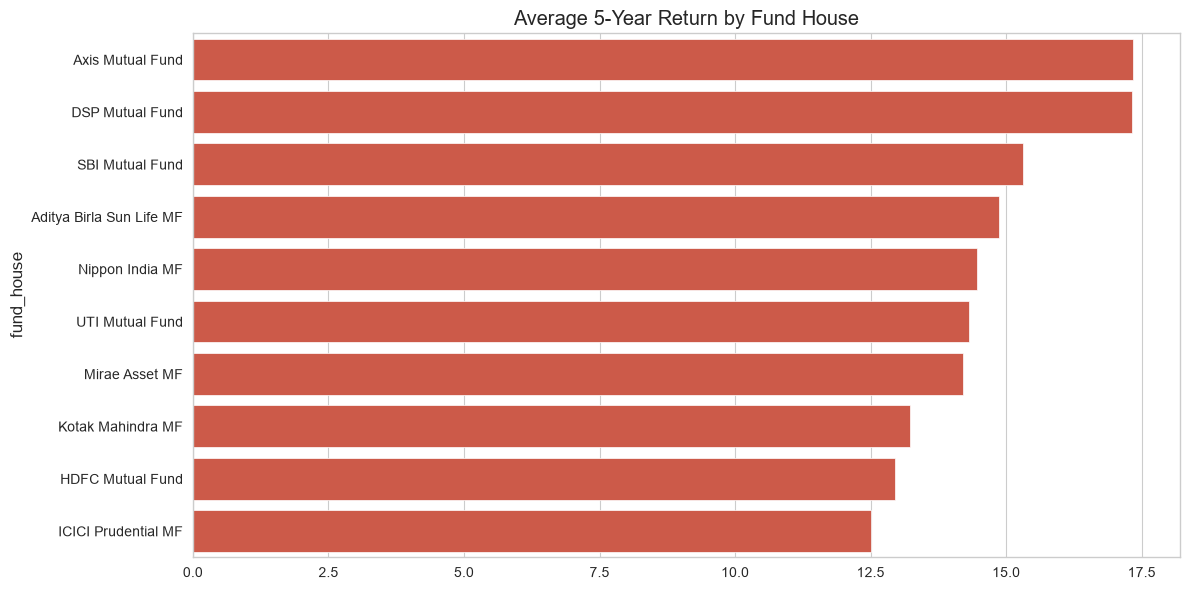

Fund House analysis saved.


In [12]:
house = (
    perf.groupby("fund_house")["return_5yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=house.values,
    y=house.index
)

plt.title("Average 5-Year Return by Fund House")

plt.tight_layout()

plt.savefig("../reports/fund_house_performance.png", dpi=300)

plt.show()

print("Fund House analysis saved.")

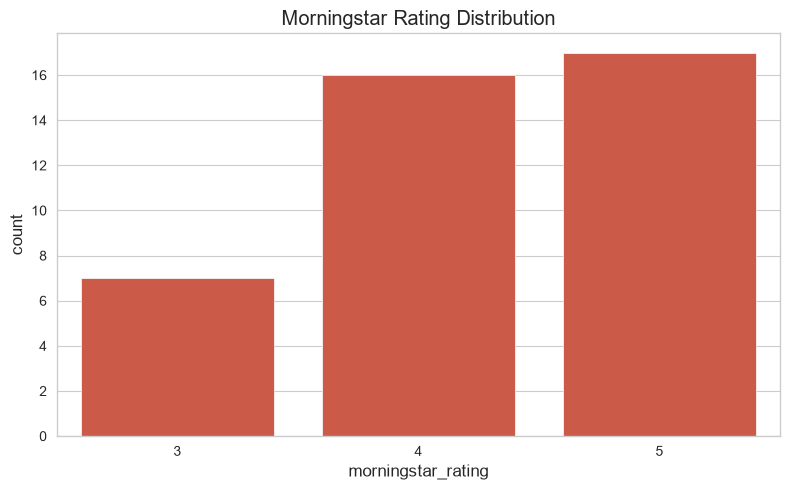

Morningstar Rating chart saved.


In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=perf,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.tight_layout()

plt.savefig("../reports/morningstar_rating.png", dpi=300)

plt.show()

print("Morningstar Rating chart saved.")

# Key Insights

## Fund Performance

- The top-performing mutual funds generated the highest 5-year returns, indicating strong long-term growth potential.
- Bottom-performing funds showed significantly lower returns and may require further evaluation before investment.

## Risk Analysis

- The Risk vs Return analysis demonstrates that higher returns generally involve higher risk.
- Investors should balance expected returns with acceptable risk levels.

## Sharpe Ratio

- Funds with higher Sharpe Ratios provide better risk-adjusted returns.
- These funds efficiently compensate investors for the risk taken.

## Alpha and Beta

- Positive Alpha indicates outperformance compared to benchmark expectations.
- Beta values close to 1 indicate market-like volatility, while higher values suggest greater market sensitivity.

## Expense Ratio

- Higher expense ratios reduce investor returns over time.
- Selecting funds with competitive expense ratios can improve long-term investment performance.

## Category Performance

- Different categories exhibited varying return characteristics.
- Equity-oriented categories generally delivered stronger long-term returns.

## Fund House Analysis

- Several fund houses consistently outperformed others based on average 5-year returns.
- Consistency of fund management plays a significant role in performance.

## Overall Conclusion

This analysis demonstrates how historical returns, risk metrics, expense ratios, and fund characteristics can be combined to evaluate mutual fund performance. Investors should consider both return and risk metrics rather than relying solely on historical returns while making investment decisions.